In [16]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(NOTEBOOK_DIR)

for _p in (PARENT_DIR, NOTEBOOK_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from solver import solve_and_execute_lqr
from visual import style_ax, COLORS

os.makedirs("result", exist_ok=True)

In [17]:
# ════════════════════════════════════════════════════════
# Part E: Merton Portfolio Problem — LQR Verification
# ════════════════════════════════════════════════════════

T_merton = 50
mu_merton = 0.10
r_merton = 0.02
sigma_merton = 0.20
gamma_merton = 2.0

# Analytical Merton solution
w_merton = (mu_merton - r_merton) / (gamma_merton * sigma_merton**2)

print(f"Merton analytical weight: {w_merton:.6f}")

# LQR formulation:
# cost = gamma * sigma^2 * w_t^2 - 2(mu-r)w_t
A_merton = np.array([[1.0]])
B_merton = np.array([[0.0]])
Q_merton = np.array([[0.0]])
R_merton = np.array([[gamma_merton * sigma_merton**2]])
M_merton = np.array([[-(mu_merton - r_merton)]])
s0_merton = np.array([1.0])

result_merton = solve_and_execute_lqr(
    T_merton,
    A_merton,
    B_merton,
    Q_merton,
    R_merton,
    M_merton,
    s0_merton
)

w_lqr = result_merton.u_path[:, 0]

print(f"LQR average weight: {np.mean(w_lqr):.6f}")
print(f"Max error: {np.max(np.abs(w_lqr - w_merton)):.2e}")
print(f"Mean error: {np.mean(np.abs(w_lqr - w_merton)):.2e}")

print(
    "\nLQR matches Merton formula:",
    np.allclose(w_lqr, w_merton, rtol=1e-8, atol=1e-10)
)

Merton analytical weight: 1.000000
LQR average weight: 1.000000
Max error: 1.11e-16
Mean error: 1.11e-16

LQR matches Merton formula: True


Saved: result/merton_validation.png


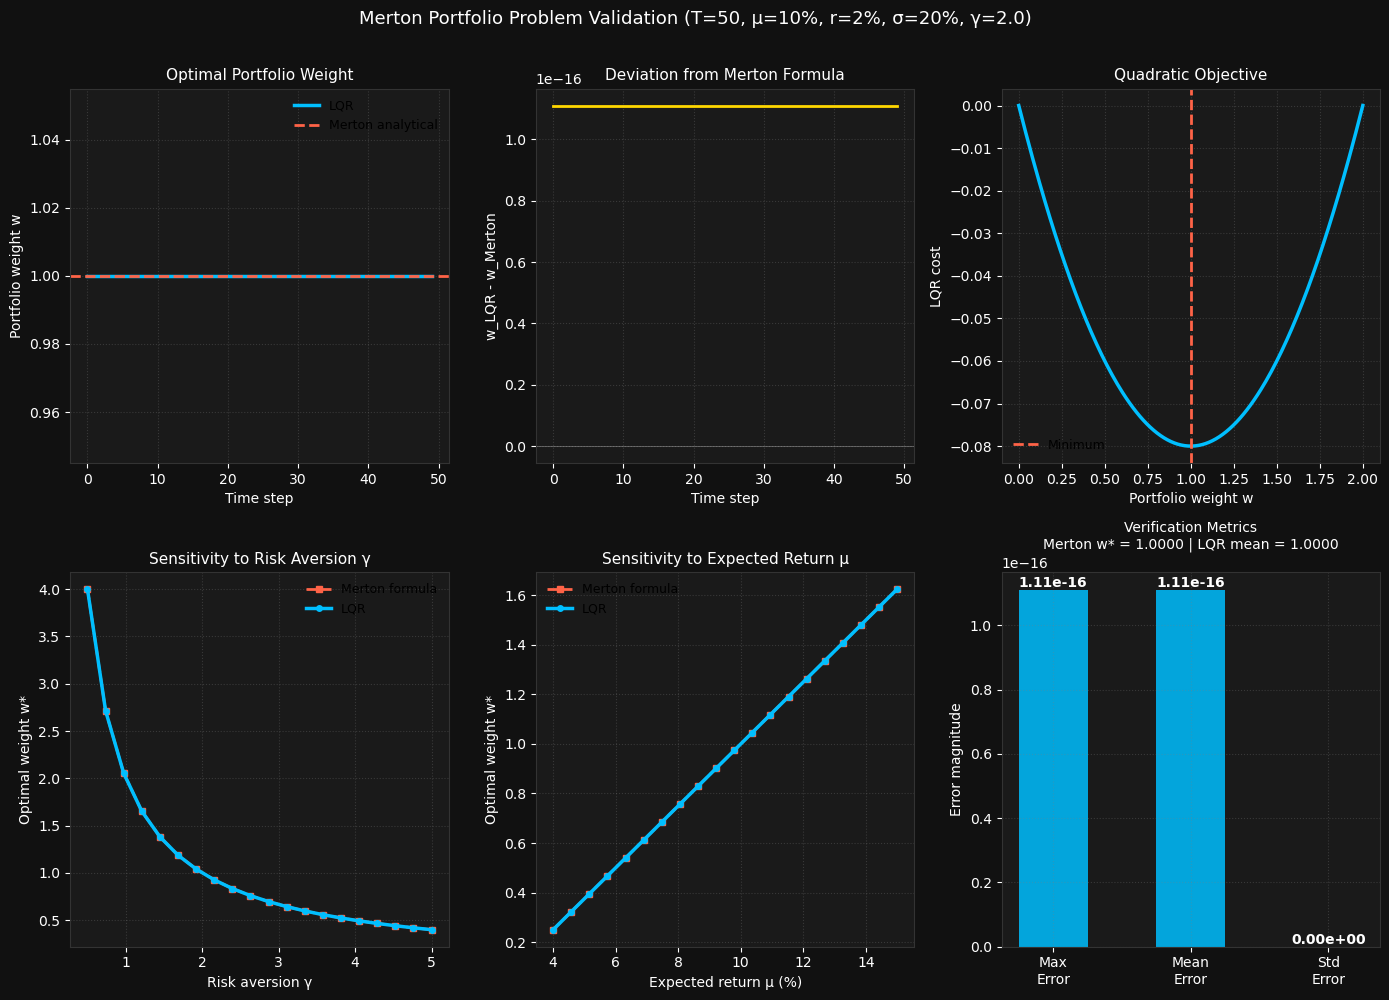

In [18]:
# ════════════════════════════════════════════════════════
# Plot Merton LQR Verification
# ════════════════════════════════════════════════════════

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor("#111111")

# ── 1: Portfolio weight over time ───────────────────────
ax1 = fig.add_subplot(2, 3, 1)
style_ax(ax1)

ax1.plot(w_lqr, color=COLORS["dp"], lw=2.5, label="LQR")
ax1.axhline(
    w_merton,
    color=COLORS["cvx"],
    lw=2,
    ls="--",
    label="Merton analytical"
)

ax1.set_title("Optimal Portfolio Weight", color="white", fontsize=11)
ax1.set_xlabel("Time step", color="white")
ax1.set_ylabel("Portfolio weight w", color="white")
ax1.legend(frameon=False, fontsize=9)


# ── 2: Error from analytical solution ───────────────────
ax2 = fig.add_subplot(2, 3, 2)
style_ax(ax2)

error = w_lqr - w_merton

ax2.plot(error, color=COLORS["gold"], lw=2)
ax2.axhline(0, color="white", lw=0.5, alpha=0.4)

ax2.set_title("Deviation from Merton Formula", color="white", fontsize=11)
ax2.set_xlabel("Time step", color="white")
ax2.set_ylabel("w_LQR - w_Merton", color="white")
ax2.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))


# ── 3: Objective shape ──────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
style_ax(ax3)

w_grid = np.linspace(0, 2 * w_merton, 200)
objective_grid = (
    gamma_merton * sigma_merton**2 * w_grid**2
    - 2 * (mu_merton - r_merton) * w_grid
)

ax3.plot(w_grid, objective_grid, color=COLORS["dp"], lw=2.5)
ax3.axvline(w_merton, color=COLORS["cvx"], lw=2, ls="--", label="Minimum")

ax3.set_title("Quadratic Objective", color="white", fontsize=11)
ax3.set_xlabel("Portfolio weight w", color="white")
ax3.set_ylabel("LQR cost", color="white")
ax3.legend(frameon=False, fontsize=9)


# ── 4: Sensitivity to gamma ─────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
style_ax(ax4)

gamma_range = np.linspace(0.5, 5.0, 20)

w_analytical_gamma = [
    (mu_merton - r_merton) / (g * sigma_merton**2)
    for g in gamma_range
]

w_lqr_gamma = []

for g in gamma_range:
    R_temp = np.array([[g * sigma_merton**2]])

    result_temp = solve_and_execute_lqr(
        T_merton,
        A_merton,
        B_merton,
        Q_merton,
        R_temp,
        M_merton,
        s0_merton
    )

    w_lqr_gamma.append(np.mean(result_temp.u_path[:, 0]))

ax4.plot(
    gamma_range,
    w_analytical_gamma,
    color=COLORS["cvx"],
    lw=2,
    ls="--",
    marker="s",
    ms=4,
    label="Merton formula"
)

ax4.plot(
    gamma_range,
    w_lqr_gamma,
    color=COLORS["dp"],
    lw=2.5,
    marker="o",
    ms=4,
    label="LQR"
)

ax4.set_title("Sensitivity to Risk Aversion γ", color="white", fontsize=11)
ax4.set_xlabel("Risk aversion γ", color="white")
ax4.set_ylabel("Optimal weight w*", color="white")
ax4.legend(frameon=False, fontsize=9)


# ── 5: Sensitivity to expected return ───────────────────
ax5 = fig.add_subplot(2, 3, 5)
style_ax(ax5)

mu_range = np.linspace(0.04, 0.15, 20)

w_analytical_mu = [
    (m - r_merton) / (gamma_merton * sigma_merton**2)
    for m in mu_range
]

w_lqr_mu = []

for m in mu_range:
    M_temp = np.array([[-(m - r_merton)]])

    result_temp = solve_and_execute_lqr(
        T_merton,
        A_merton,
        B_merton,
        Q_merton,
        R_merton,
        M_temp,
        s0_merton
    )

    w_lqr_mu.append(np.mean(result_temp.u_path[:, 0]))

ax5.plot(
    mu_range * 100,
    w_analytical_mu,
    color=COLORS["cvx"],
    lw=2,
    ls="--",
    marker="s",
    ms=4,
    label="Merton formula"
)

ax5.plot(
    mu_range * 100,
    w_lqr_mu,
    color=COLORS["dp"],
    lw=2.5,
    marker="o",
    ms=4,
    label="LQR"
)

ax5.set_title("Sensitivity to Expected Return μ", color="white", fontsize=11)
ax5.set_xlabel("Expected return μ (%)", color="white")
ax5.set_ylabel("Optimal weight w*", color="white")
ax5.legend(frameon=False, fontsize=9)


# ── 6: Error metrics ────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
style_ax(ax6)

metrics = ["Max\nError", "Mean\nError", "Std\nError"]
values = [
    np.abs(error).max(),
    np.abs(error).mean(),
    np.abs(error).std()
]

bars = ax6.bar(metrics, values, color=COLORS["dp"], width=0.5, alpha=0.85)

for bar, val in zip(bars, values):
    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2e}",
        ha="center",
        va="bottom",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

ax6.set_title(
    f"Verification Metrics\n"
    f"Merton w* = {w_merton:.4f} | LQR mean = {np.mean(w_lqr):.4f}",
    color="white",
    fontsize=10
)

ax6.set_ylabel("Error magnitude", color="white")
ax6.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))


fig.suptitle(
    f"Merton Portfolio Problem Validation "
    f"(T={T_merton}, μ={mu_merton*100:.0f}%, r={r_merton*100:.0f}%, "
    f"σ={sigma_merton*100:.0f}%, γ={gamma_merton:.1f})",
    color="white",
    fontsize=13,
    y=0.995
)

plt.tight_layout()
plt.savefig(
    "result/merton_validation.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#111111"
)

print("Saved: result/merton_validation.png")
plt.show()